In [27]:
import librosa
import numpy as np
import os
import soundfile as sf

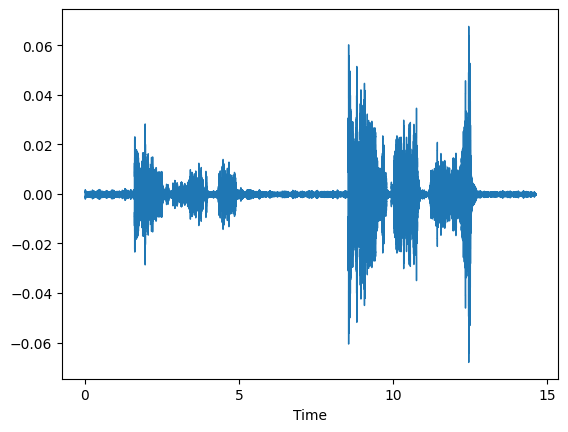

In [30]:
#load /Users/dorry/Desktop/research/test_one/twig/audio_1653223324786523995.wav
base_path = os.path.join('./test_one/twig/audio_1653223324786523995.wav')
y, sr = librosa.load(base_path)

#play the audio
librosa.display.waveshow(y, sr=sr)



Total segments saved:  5715
Visualizing: ./test/trunk/audio_1653226471702937346.wav


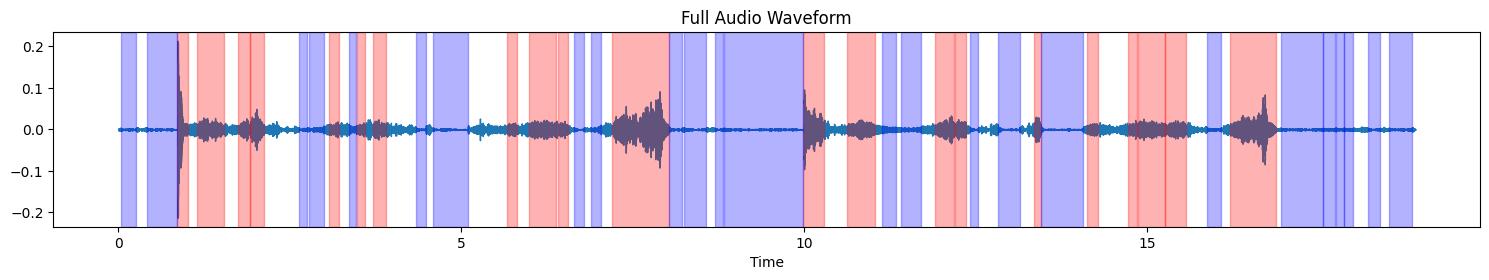

In [25]:
import librosa
import numpy as np
import os
import soundfile as sf
import matplotlib.pyplot as plt
import random

def apply_fade(audio, sr, fade_duration=0.01):
    fade_length = int(fade_duration * sr)
    fade_in = np.linspace(0, 1, fade_length)
    fade_out = np.linspace(1, 0, fade_length)
    
    audio[:fade_length] *= fade_in
    audio[-fade_length:] *= fade_out
    return audio

def segment_audio(audio_path, visualize=False):
    # Set a threshold for amplitude - adjusted for better sensitivity
    threshold = 0.003  # Lowered threshold to catch more segments

    # Load the audio file with a smaller frame length
    y, sr = librosa.load(audio_path, duration=None)
    
    # Reduce minimum duration to catch shorter sounds
    min_duration = 0.1  # 100ms minimum duration
    min_samples = int(min_duration * sr)
    
    # Shorter silence duration for more precise segmentation
    silence_duration = 0.1
    silence_samples = int(silence_duration * sr)
    
    # Apply a small amount of smoothing to reduce noise
    y_smooth = np.convolve(np.abs(y), np.ones(int(0.01*sr))/int(0.01*sr), mode='same')
    
    # Create masks using smoothed signal
    loud_mask = y_smooth > threshold
    silent_mask = ~loud_mask

    # Track both types of segments
    loud_segments = []
    silent_segments = []
    current_loud_segment = []
    current_silent_segment = []
    silence_count = 0

    for i, (is_loud, is_silent) in enumerate(zip(loud_mask, silent_mask)):
        if is_loud:
            if silence_count >= silence_samples and current_loud_segment:
                if len(current_loud_segment) >= min_samples:
                    loud_segments.append((current_loud_segment[0], current_loud_segment[-1]))
                current_loud_segment = []
            current_loud_segment.append(i)
            
            # Close any open silent segment
            if current_silent_segment and len(current_silent_segment) >= min_samples:
                silent_segments.append((current_silent_segment[0], current_silent_segment[-1]))
            current_silent_segment = []
            silence_count = 0
        else:
            silence_count += 1
            current_silent_segment.append(i)
            
            # Close any open loud segment
            if current_loud_segment and len(current_loud_segment) >= min_samples:
                loud_segments.append((current_loud_segment[0], current_loud_segment[-1]))
            current_loud_segment = []

    # Close any remaining segments
    if current_loud_segment and len(current_loud_segment) >= min_samples:
        loud_segments.append((current_loud_segment[0], current_loud_segment[-1]))
    if current_silent_segment and len(current_silent_segment) >= min_samples:
        silent_segments.append((current_silent_segment[0], current_silent_segment[-1]))

    # If visualization is requested
    if visualize:
        plt.figure(figsize=(15, 5))
        
        # Plot full waveform
        plt.subplot(2, 1, 1)
        plt.title('Full Audio Waveform')
        librosa.display.waveshow(y, sr=sr)
        
        # Highlight segments if any exist
        if loud_segments:
            for start, end in loud_segments:
                plt.axvspan(start/sr, end/sr, color='red', alpha=0.3)
        if silent_segments:
            for start, end in silent_segments:
                plt.axvspan(start/sr, end/sr, color='blue', alpha=0.3)
        
        plt.tight_layout()
        plt.show()

    # Save loud segments in original category
    category = os.path.basename(os.path.dirname(audio_path))
    output_dir = os.path.join('output', category)
    os.makedirs(output_dir, exist_ok=True)

    # Create ambient category directory
    ambient_dir = os.path.join('output', 'ambient')
    os.makedirs(ambient_dir, exist_ok=True)

    base_filename = os.path.splitext(os.path.basename(audio_path))[0]
    
    # If no segments were found at all, save full audio in original category
    if not loud_segments and not silent_segments:
        output_filename = os.path.join(output_dir, f'{base_filename}_full.wav')
        sf.write(output_filename, y, sr)
        return 1

    total_segments = 0

    # Save loud segments in original category
    for idx, (start, end) in enumerate(loud_segments):
        segment_audio = y[start:end]
        segment_audio = apply_fade(segment_audio.copy(), sr)  # Apply fade to a copy of the segment
        output_filename = os.path.join(output_dir, f'{base_filename}_{idx+1}.wav')
        sf.write(output_filename, segment_audio, sr)
        total_segments += 1

    # Save silent segments in ambient category
    for idx, (start, end) in enumerate(silent_segments):
        segment_audio = y[start:end]
        segment_audio = apply_fade(segment_audio.copy(), sr)  # Apply fade to a copy of the segment
        output_filename = os.path.join(ambient_dir, f'{base_filename}_ambient_{idx+1}.wav')
        sf.write(output_filename, segment_audio, sr)
        total_segments += 1

    return total_segments

def visualize_random_audio():
    audio_files = []
    for category in os.listdir('./test'):
        category_path = os.path.join('./test', category)
        if os.path.isdir(category_path):
            for file in os.listdir(category_path):
                audio_path = os.path.join(category_path, file)
                if os.path.isfile(audio_path):
                    audio_files.append(audio_path)
    
    if audio_files:
        random_file = random.choice(audio_files)
        print(f"Visualizing: {random_file}")
        segment_audio(random_file, visualize=True)
    else:
        print("No audio files found")

# Process all audio files
count = 0
for category in os.listdir('./test'):
    category_path = os.path.join('./test', category)
    if os.path.isdir(category_path):
        for file in os.listdir(category_path):
            audio_path = os.path.join(category_path, file)
            if os.path.isfile(audio_path):
                count += segment_audio(audio_path)

print("Total segments saved: ", count)

# Visualize a random audio file
visualize_random_audio()

Total segments saved:  4727
Visualizing: ./test/trunk/audio_1653241560136714295.wav


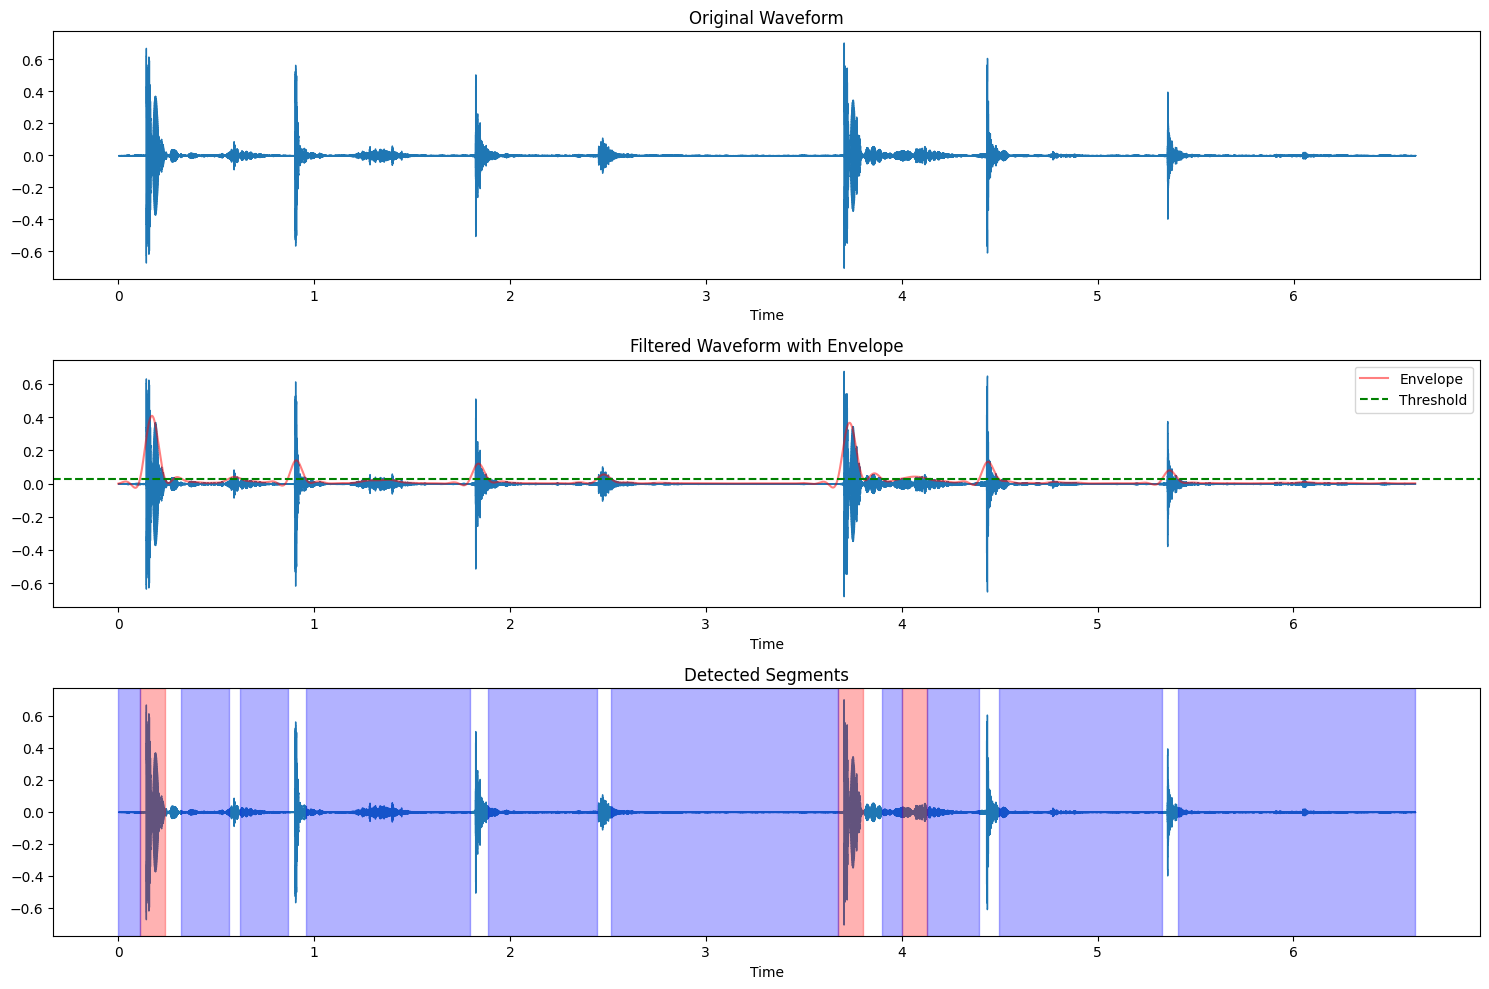

In [1]:
import librosa
import numpy as np
import os
import soundfile as sf
import matplotlib.pyplot as plt
import random
from scipy.signal import butter, filtfilt, hilbert

def butter_lowpass(cutoff, fs, order=5):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return b, a

def apply_lowpass_filter(data, cutoff, fs, order=5):
    b, a = butter_lowpass(cutoff, fs, order=order)
    y = filtfilt(b, a, data)
    return y

def get_envelope(data, fs, cutoff=10):
    # Get amplitude envelope using Hilbert transform
    analytic_signal = hilbert(data)
    amplitude_envelope = np.abs(analytic_signal)
    
    # Apply low-pass filter to smooth the envelope
    smooth_envelope = apply_lowpass_filter(amplitude_envelope, cutoff, fs)
    return smooth_envelope

def apply_fade(audio, sr, fade_duration=0.01):
    fade_length = int(fade_duration * sr)
    fade_in = np.linspace(0, 1, fade_length)
    fade_out = np.linspace(1, 0, fade_length)
    
    audio[:fade_length] *= fade_in
    audio[-fade_length:] *= fade_out
    return audio

def segment_audio(audio_path, visualize=False):
    # Load the audio file
    y, sr = librosa.load(audio_path, duration=None)
    
    # Apply initial low-pass filter to remove high-frequency noise
    y_filtered = apply_lowpass_filter(y, cutoff=1000, fs=sr)
    
    # Get the amplitude envelope
    envelope = get_envelope(y_filtered, sr, cutoff=10)
    
    # Parameters for segmentation
    threshold = np.mean(envelope) * 1.5  # Adaptive threshold based on mean envelope
    min_duration = 0.1  # seconds
    min_samples = int(min_duration * sr)
    silence_duration = 0.1  # seconds
    silence_samples = int(silence_duration * sr)
    
    # Create masks using envelope
    loud_mask = envelope > threshold
    silent_mask = ~loud_mask

    # Track segments
    loud_segments = []
    silent_segments = []
    current_loud_segment = []
    current_silent_segment = []
    silence_count = 0

    for i, (is_loud, is_silent) in enumerate(zip(loud_mask, silent_mask)):
        if is_loud:
            if silence_count >= silence_samples and current_loud_segment:
                if len(current_loud_segment) >= min_samples:
                    loud_segments.append((current_loud_segment[0], current_loud_segment[-1]))
                current_loud_segment = []
            current_loud_segment.append(i)
            
            if current_silent_segment and len(current_silent_segment) >= min_samples:
                silent_segments.append((current_silent_segment[0], current_silent_segment[-1]))
            current_silent_segment = []
            silence_count = 0
        else:
            silence_count += 1
            current_silent_segment.append(i)
            
            if current_loud_segment and len(current_loud_segment) >= min_samples:
                loud_segments.append((current_loud_segment[0], current_loud_segment[-1]))
            current_loud_segment = []

    # Close remaining segments
    if current_loud_segment and len(current_loud_segment) >= min_samples:
        loud_segments.append((current_loud_segment[0], current_loud_segment[-1]))
    if current_silent_segment and len(current_silent_segment) >= min_samples:
        silent_segments.append((current_silent_segment[0], current_silent_segment[-1]))

    # Visualization
    if visualize:
        plt.figure(figsize=(15, 10))
        
        # Plot original waveform
        plt.subplot(3, 1, 1)
        plt.title('Original Waveform')
        librosa.display.waveshow(y, sr=sr)
        
        # Plot filtered waveform
        plt.subplot(3, 1, 2)
        plt.title('Filtered Waveform with Envelope')
        librosa.display.waveshow(y_filtered, sr=sr)
        plt.plot(np.arange(len(envelope))/sr, envelope, 'r', alpha=0.5, label='Envelope')
        plt.axhline(y=threshold, color='g', linestyle='--', label='Threshold')
        plt.legend()
        
        # Plot segments
        plt.subplot(3, 1, 3)
        plt.title('Detected Segments')
        librosa.display.waveshow(y, sr=sr)
        
        if loud_segments:
            for start, end in loud_segments:
                plt.axvspan(start/sr, end/sr, color='red', alpha=0.3)
        if silent_segments:
            for start, end in silent_segments:
                plt.axvspan(start/sr, end/sr, color='blue', alpha=0.3)
        
        plt.tight_layout()
        plt.show()

    # Save segments
    category = os.path.basename(os.path.dirname(audio_path))
    output_dir = os.path.join('output', category)
    os.makedirs(output_dir, exist_ok=True)
    
    ambient_dir = os.path.join('output', 'ambient')
    os.makedirs(ambient_dir, exist_ok=True)

    base_filename = os.path.splitext(os.path.basename(audio_path))[0]
    
    if not loud_segments and not silent_segments:
        output_filename = os.path.join(output_dir, f'{base_filename}_full.wav')
        sf.write(output_filename, y, sr)
        return 1

    total_segments = 0

    # Save loud segments
    for idx, (start, end) in enumerate(loud_segments):
        segment_audio = y[start:end]
        segment_audio = apply_fade(segment_audio.copy(), sr)
        output_filename = os.path.join(output_dir, f'{base_filename}_{idx+1}.wav')
        sf.write(output_filename, segment_audio, sr)
        total_segments += 1

    # Save silent segments
    for idx, (start, end) in enumerate(silent_segments):
        segment_audio = y[start:end]
        segment_audio = apply_fade(segment_audio.copy(), sr)
        output_filename = os.path.join(ambient_dir, f'{base_filename}_ambient_{idx+1}.wav')
        sf.write(output_filename, segment_audio, sr)
        total_segments += 1

    return total_segments

def visualize_random_audio():
    audio_files = []
    for category in os.listdir('./test'):
        category_path = os.path.join('./test', category)
        if os.path.isdir(category_path):
            for file in os.listdir(category_path):
                audio_path = os.path.join(category_path, file)
                if os.path.isfile(audio_path):
                    audio_files.append(audio_path)
    
    if audio_files:
        random_file = random.choice(audio_files)
        print(f"Visualizing: {random_file}")
        segment_audio(random_file, visualize=True)
    else:
        print("No audio files found")

# Process all audio files
count = 0
for category in os.listdir('./test'):
    category_path = os.path.join('./test', category)
    if os.path.isdir(category_path):
        for file in os.listdir(category_path):
            audio_path = os.path.join(category_path, file)
            if os.path.isfile(audio_path):
                count += segment_audio(audio_path)

print("Total segments saved: ", count)

# Visualize a random audio file
visualize_random_audio()

In [47]:
count = 0
for category in os.listdir('./test'):
    category_path = os.path.join('./test', category)
    if os.path.isdir(category_path):
        for file in os.listdir(category_path):
            audio_path = os.path.join(category_path, file)
            if os.path.isfile(audio_path):
                count += segment_audio(audio_path)

print("Total segments saved: ", count)

Total segments saved:  831


In [ ]:
import librosa
import numpy as np
import os
import soundfile as sf
import matplotlib.pyplot as plt
import random
from audio_segmentation import segment_audio as segment_audio_core

def apply_fade(audio, sr, fade_duration=0.01):
# ... existing code ...

def segment_audio(audio_path, visualize=False):
# Load the audio file
y, sr = librosa.load(audio_path, duration=None)

# Use the core segmentation function from audio_segmentation.py
segments_and_states = segment_audio_core(audio_path, window_size=1000, threshold_multiplier=1.5)

# Separate into loud and silent segments based on states
loud_segments = []
silent_segments = []

current_pos = 0
for segment, is_contact in segments_and_states:
    segment_length = len(segment)
    if is_contact:
        loud_segments.append((current_pos, current_pos + segment_length))
    else:
        silent_segments.append((current_pos, current_pos + segment_length))
    current_pos += segment_length

# Visualization logic
if visualize:
    plt.figure(figsize=(15, 5))
    plt.title('Audio Waveform with Segments')
    librosa.display.waveshow(y, sr=sr)
    
    if loud_segments:
        for start, end in loud_segments:
            plt.axvspan(start/sr, end/sr, color='red', alpha=0.3, label='Contact')
    if silent_segments:
        for start, end in silent_segments:
            plt.axvspan(start/sr, end/sr, color='blue', alpha=0.3, label='Non-contact')
    
    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    plt.legend(by_label.values(), by_label.keys())
    plt.tight_layout()
    plt.show()

# Save segments logic
category = os.path.basename(os.path.dirname(audio_path))
output_dir = os.path.join('output', category)
ambient_dir = os.path.join('output', 'ambient')
os.makedirs(output_dir, exist_ok=True)
os.makedirs(ambient_dir, exist_ok=True)

base_filename = os.path.splitext(os.path.basename(audio_path))[0]

if not loud_segments and not silent_segments:
    output_filename = os.path.join(output_dir, f'{base_filename}_full.wav')
    sf.write(output_filename, y, sr)
    return 1

total_segments = 0

# Save segments
for idx, (start, end) in enumerate(loud_segments):
    segment_audio = y[start:end]
    segment_audio = apply_fade(segment_audio.copy(), sr)
    output_filename = os.path.join(output_dir, f'{base_filename}_{idx+1}.wav')
    sf.write(output_filename, segment_audio, sr)
    total_segments += 1

for idx, (start, end) in enumerate(silent_segments):
    segment_audio = y[start:end]
    segment_audio = apply_fade(segment_audio.copy(), sr)
    output_filename = os.path.join(ambient_dir, f'{base_filename}_ambient_{idx+1}.wav')
    sf.write(output_filename, segment_audio, sr)
    total_segments += 1

return total_segments

# ... rest of the existing code (visualize_random_audio and processing loop) ...